# 01 — Data & Exploratory Analysis

Goals:
- Validate Tier-1 and Tier-2 features
- Analyse PETSc solver results and define clean labels
- Build the joined ML dataset
- Explore feature distributions and solver behaviour

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 60)
FIG_DIR = Path('results/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Load raw data ──────────────────────────────────────────────────────────
df_t1  = pd.read_csv('../data/processed/tier1_features.csv', index_col=0)
df_t12 = pd.read_csv('../data/processed/tier12_features.csv')
df_sol = pd.read_csv('../data/processed/solver_results.csv')

print('Tier-1 features:', df_t1.shape)
print('Tier-1+2 features:', df_t12.shape)
print('Solver results:', df_sol.shape)

Tier-1 features: (808, 15)
Tier-1+2 features: (808, 32)
Solver results: (6392, 15)


## 1 · Feature validation

In [16]:
TIER1_COLS = [
    'nrows','ncols','nnz','density',
    'nnz_per_row_mean','nnz_per_row_std','nnz_per_row_min','nnz_per_row_max',
    'zero_diag_fraction','diag_abs_mean','diag_abs_std','diag_dominance_fraction',
    'norm_1','norm_inf','symmetry_score_struct'
]
TIER2_COLS = [
    'row_norm2_mean','row_norm2_std','row_norm2_min','row_norm2_max',
    'col_norm2_mean','col_norm2_std','col_norm2_min','col_norm2_max',
    'diag_abs_min','diag_abs_max','tiny_diag_fraction',
    'symmetry_numeric_fro_ratio','spec_radius_est',
    'sigma_max_est_power','row_norm2_spread','pseudo_kappa'
]
# Log-scale features (used consistently throughout all notebooks)
LOG_FEATURES = [
    'pseudo_kappa','spec_radius_est','sigma_max_est_power','row_norm2_spread',
    'norm_inf','norm_1','row_norm2_mean','row_norm2_std','row_norm2_max',
    'col_norm2_mean','col_norm2_std','col_norm2_max'
]

print('NaNs in Tier-1:')
print(df_t1.isna().sum()[df_t1.isna().sum() > 0])
print('\nDuplicates:', df_t1.index.duplicated().sum())
df_t1[TIER1_COLS].describe().T

NaNs in Tier-1:
Series([], dtype: int64)

Duplicates: 0


,count,mean,std,min,25%,50%,75%,max
nrows,808.0,2.191318e+04,2.114183e+05,3.400000e+01,1220.000000,2175.500000,5051.250000,5.154859e+06
ncols,808.0,2.191318e+04,2.114183e+05,3.400000e+01,1220.000000,2175.500000,5051.250000,5.154859e+06
nnz,808.0,5.687907e+05,5.466197e+06,3.100000e+01,8000.000000,20813.000000,56175.000000,9.919955e+07
density,808.0,6.692891e-03,1.142147e-02,1.710623e-06,0.001469,0.003476,0.006942,1.349481e-01
nnz_per_row_mean,808.0,1.527914e+01,2.475546e+01,7.282124e-03,4.865517,6.890672,14.857588,2.919183e+02
nnz_per_row_std,808.0,1.376619e+01,2.294921e+01,0.000000e+00,1.964167,5.897783,16.887843,3.236464e+02
nnz_per_row_min,808.0,3.643564e+00,8.267173e+00,0.000000e+00,1.000000,1.500000,4.000000,1.820000e+02
nnz_per_row_max,808.0,3.804790e+02,8.848605e+02,1.000000e+00,12.000000,42.000000,280.000000,1.040500e+04
zero_diag_fraction,808.0,2.786806e-01,3.942771e-01,0.000000e+00,0.000000,0.006619,0.439345,1.000000e+00
diag_abs_mean,808.0,2.199075e+25,6.250945e+26,0.000000e+00,0.002554,0.948724,67.130980,1.776852e+28


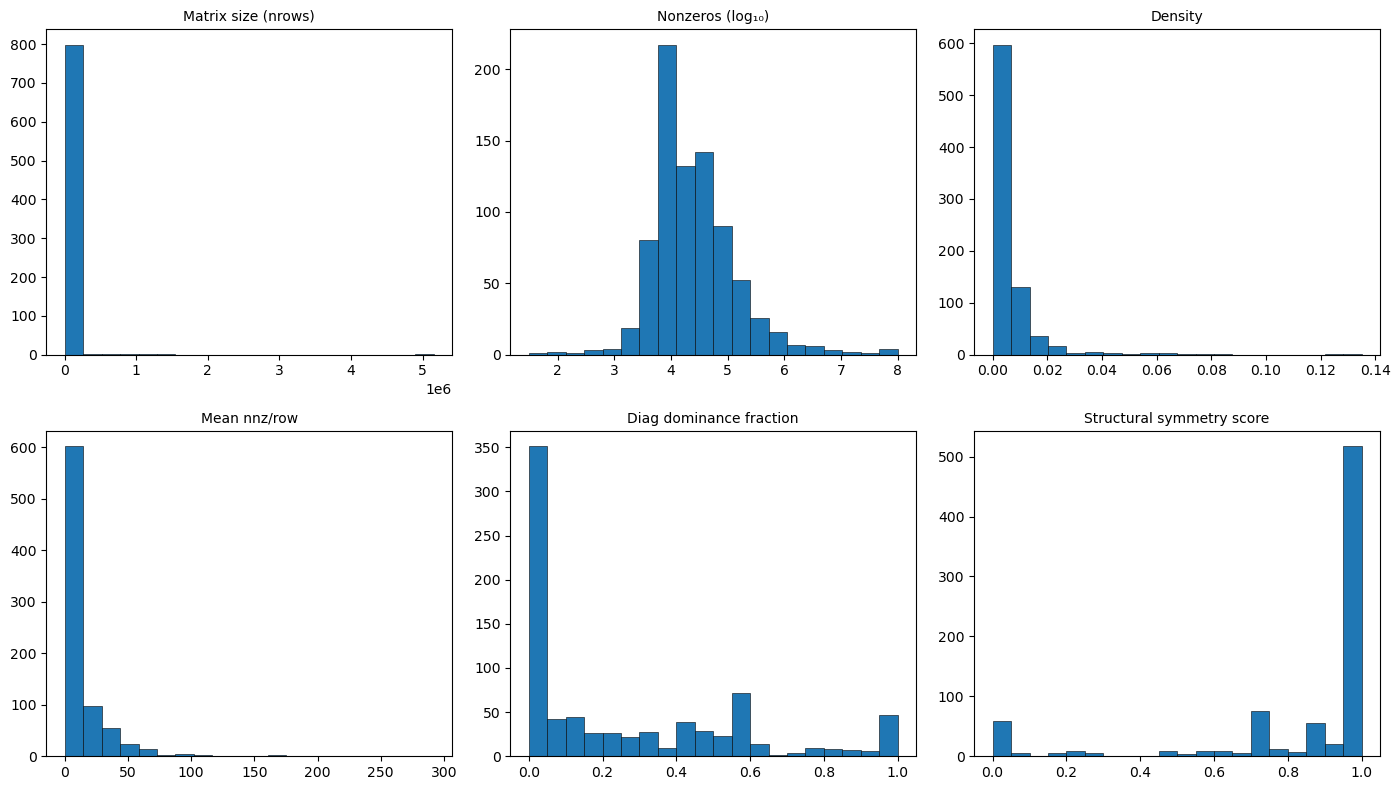

In [17]:
# Key distributions
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plots = [
    ('nrows',                   'Matrix size (nrows)',          False),
    ('nnz',                     'Nonzeros (log₁₀)',            True),
    ('density',                 'Density',                     False),
    ('nnz_per_row_mean',        'Mean nnz/row',                False),
    ('diag_dominance_fraction', 'Diag dominance fraction',     False),
    ('symmetry_score_struct',   'Structural symmetry score',   False),
]
for ax, (col, title, logx) in zip(axes.flat, plots):
    vals = df_t1[col].dropna()
    ax.hist(np.log10(vals.clip(1e-30)) if logx else vals, bins=20, edgecolor='k', linewidth=0.4)
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'feature_distributions.png', dpi=150)
plt.show()

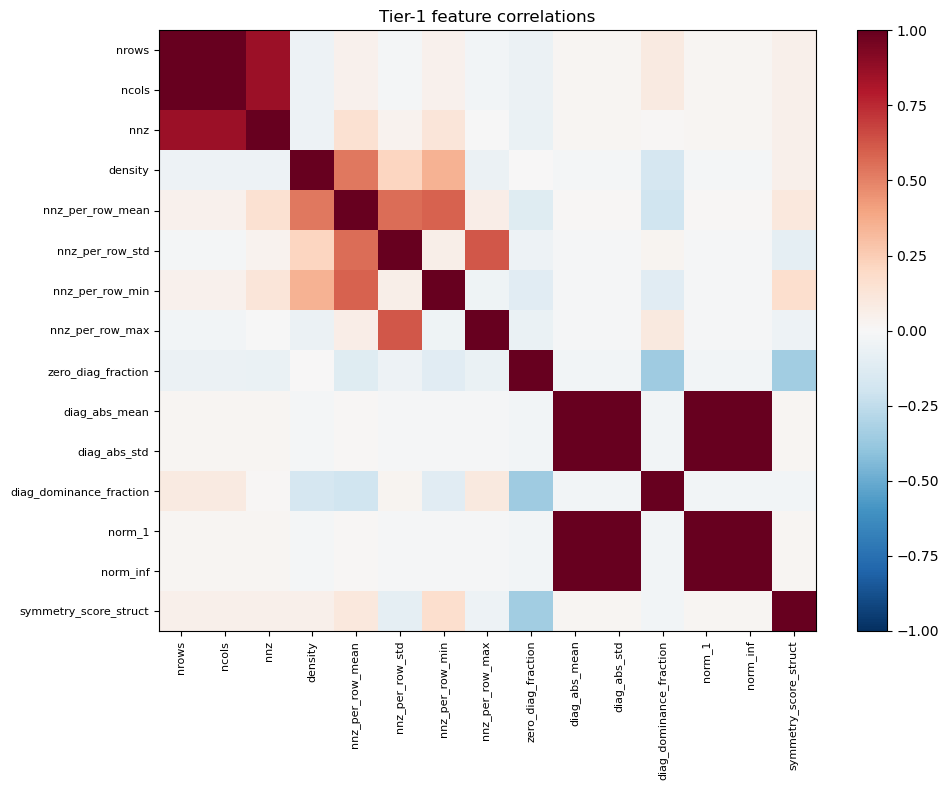

nrows          ncols            1.0
norm_inf       norm_1           1.0
diag_abs_std   diag_abs_mean    1.0
ncols          nrows            1.0
norm_1         norm_inf         1.0
diag_abs_mean  diag_abs_std     1.0
diag_abs_std   norm_inf         1.0
norm_inf       diag_abs_mean    1.0
norm_1         diag_abs_std     1.0
norm_inf       diag_abs_std     1.0
dtype: float64

In [19]:
# Tier-1 correlation heatmap
corr = df_t1[TIER1_COLS].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(TIER1_COLS))); ax.set_xticklabels(TIER1_COLS, rotation=90, fontsize=8)
ax.set_yticks(range(len(TIER1_COLS))); ax.set_yticklabels(TIER1_COLS, fontsize=8)
plt.colorbar(im, ax=ax)
plt.title('Tier-1 feature correlations')
plt.tight_layout()
plt.savefig(FIG_DIR / 'corr_tier1.png', dpi=150)
plt.show()

# Top correlated pairs
corr_abs = corr.abs()
mask = ~np.eye(len(corr_abs), dtype=bool)
corr_abs.where(mask).stack().sort_values(ascending=False).head(10)

## 2 · Solver results — labels and dataset construction

In [20]:
# PETSc reason codes:
# > 0 → converged  |  -3 → max iters  |  -10 → ILU failed  |  -998/-999 → exception
def is_applicable(row):
    if row['reason'] in (-10, -998, -999): return 0
    if row['ksp'] == 'cg' and row['reason'] == 5: return 0  # CG needs SPD
    return 1

df_sol['applicable']      = df_sol.apply(is_applicable, axis=1)
df_sol['converged_clean'] = (df_sol['reason'] > 0) & (df_sol['applicable'] == 1)
df_sol['iterations_clean'] = np.where(df_sol['converged_clean'], df_sol['iterations'], np.nan)

print('Solver config summary:')
df_sol.groupby(['ksp','pc']).agg(
    runs=('matrix_id','count'),
    applicable_rate=('applicable','mean'),
    converge_rate=('converged_clean','mean'),
    mean_iters=('iterations_clean','mean')
).round(3)

Solver config summary:


runs  applicable_rate  converge_rate  mean_iters
ksp    pc                                                      
bcgs   ilu      799            0.422          0.232      70.054
       jacobi   799            1.000          0.263     114.138
cg     jacobi   799            0.437          0.103     111.756
fgmres jacobi   799            1.000          0.154     115.748
gmres  ilu      799            0.422          0.193      70.442
       jacobi   799            1.000          0.198      83.152
minres jacobi   799            1.000          0.189     149.662
tfqmr  jacobi   799            1.000          0.290     114.862

In [21]:
# Join solver results with Tier-1+2 features
df = df_sol.merge(df_t12, on='matrix_id', how='left', suffixes=('','_dup'))
df = df.loc[:, ~df.columns.str.endswith('_dup')]

# Fast/slow label: within 10% of best solver per matrix (converged runs only)
df_conv = df[df['converged_clean']].copy()
df_conv['best_time'] = df_conv.groupby('matrix_id')['solve_time_sec'].transform('min')
df_conv['fast_label'] = (df_conv['solve_time_sec'] <= 1.10 * df_conv['best_time']).astype(int)

print('Full joined dataset:', df.shape)
print('Converged-only (fast/slow):', df_conv.shape)
print('Fast label balance:', df_conv['fast_label'].value_counts().to_dict())

df.to_csv('../data/processed/ml_dataset_full.csv', index=False)
df_conv.to_csv('../data/processed/ml_dataset_converged.csv', index=False)
print('\nDatasets saved.')

Full joined dataset: (6392, 47)
Converged-only (fast/slow): (1295, 49)
Fast label balance: {0: 832, 1: 463}

Datasets saved.


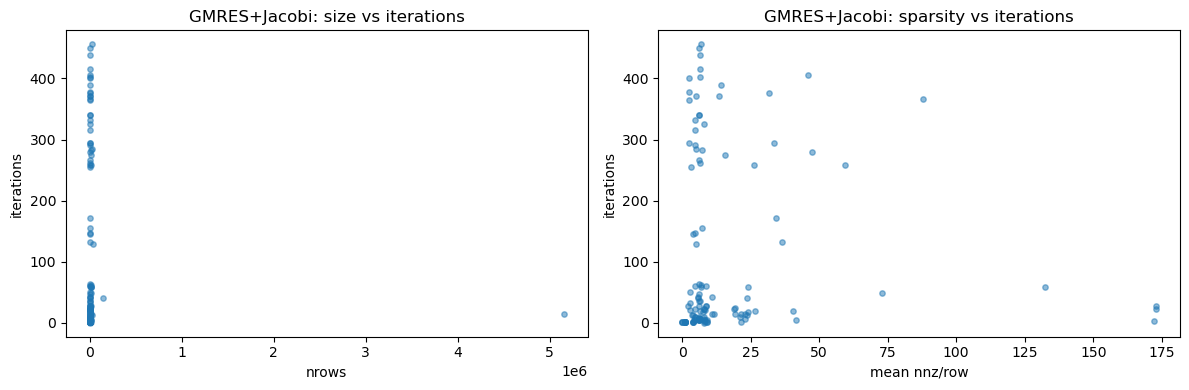

In [22]:
# Solver behaviour — GMRES+Jacobi scatter
g = df_conv[(df_conv['ksp']=='gmres') & (df_conv['pc']=='jacobi')]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(g['nrows'], g['iterations_clean'], alpha=0.5, s=15)
axes[0].set(xlabel='nrows', ylabel='iterations', title='GMRES+Jacobi: size vs iterations')
axes[1].scatter(g['nnz_per_row_mean'], g['iterations_clean'], alpha=0.5, s=15)
axes[1].set(xlabel='mean nnz/row', ylabel='iterations', title='GMRES+Jacobi: sparsity vs iterations')
plt.tight_layout()
plt.show()

In [25]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import time
import numpy as np
import pandas as pd
from scipy.io import mmread
from pathlib import Path
from src.features.tier1 import extract_tier1_features, Tier1Config
from src.features.tier2 import extract_tier2_features, Tier2Config
import scipy.sparse as sp

# Pick a representative matrix for per-matrix timing
sample_matrices = list(Path('../data/matrices_new').glob('*.mtx'))[:20]

tier1_times = []
tier2_times = []

for p in sample_matrices:
    try:
        A = mmread(str(p))
        if not sp.issparse(A):
            A = sp.csr_matrix(A)
        A = A.tocsr().astype(float)

        # Time Tier-1
        t0 = time.perf_counter()
        extract_tier1_features(A, Tier1Config())
        tier1_times.append(time.perf_counter() - t0)

        # Time Tier-2
        t0 = time.perf_counter()
        extract_tier2_features(A, Tier2Config())
        tier2_times.append(time.perf_counter() - t0)

    except Exception:
        continue

print(f'Tier-1  — mean: {np.mean(tier1_times)*1000:.1f} ms, '
      f'median: {np.median(tier1_times)*1000:.1f} ms')
print(f'Tier-2  — mean: {np.mean(tier2_times)*1000:.1f} ms, '
      f'median: {np.median(tier2_times)*1000:.1f} ms')
print(f'Tier-1+2 — mean: {(np.mean(tier1_times)+np.mean(tier2_times))*1000:.1f} ms')

Tier-1  — mean: 48.9 ms, median: 23.0 ms
Tier-2  — mean: 5.5 ms, median: 2.1 ms
Tier-1+2 — mean: 54.4 ms


In [27]:
df = pd.read_csv('../data/processed/ml_dataset_full.csv')

# Best solver time per matrix (fastest converged run)
best_times = (df[df['converged_clean'] == True]
              .groupby('matrix_id')['solve_time_sec']
              .min())

# Average time if you run ALL configs (what you'd do without prediction)
all_configs_time = (df[df['converged_clean'] == True]
                    .groupby('matrix_id')['solve_time_sec']
                    .sum())

print(f'Average best solver time per matrix: '
      f'{best_times.mean()*1000:.1f} ms')
print(f'Average total time running all configs: '
      f'{all_configs_time.mean()*1000:.1f} ms')
print(f'Average Tier-1+2 extraction time: '
      f'{(np.mean(tier1_times)+np.mean(tier2_times))*1000:.1f} ms')

# The key ratio
ratio = (np.mean(tier1_times) + np.mean(tier2_times)) / best_times.mean()
print(f'\nFeature extraction / best solve time ratio: {ratio:.2f}x')

speedup = all_configs_time.mean() / (
    np.mean(tier1_times) + np.mean(tier2_times) + best_times.mean())
print(f'Speedup of predict-then-solve vs try-all: {speedup:.1f}x')

Average best solver time per matrix: 113.6 ms
Average total time running all configs: 3143.9 ms
Average Tier-1+2 extraction time: 54.4 ms

Feature extraction / best solve time ratio: 0.48x
Speedup of predict-then-solve vs try-all: 18.7x
